🤖 TURTLEBOT3 Q-LEARNING EĞİTİMİ - İYİLEŞTİRİLMİŞ
📌 7 LIDAR noktası → 4 seviyeye diskretize edildi
📌 Her 50 episodeda bir görsel kaydedilecek
📌 Diğer zamanlarda görselleştirme KAPALI (hızlı eğitim)

🚀 Q-Learning Eğitimi başlıyor...
📊 Max Steps: 600
📊 Her 50 episodeda bir görsel kaydedilecek
📊 İlk episode (Episode 1) için de görsel kaydedilecek

📸 Görsel kaydedildi: training_screenshots/episode_0001.png
📊 Episode    1/3000 | Reward:    38.56 | Epsilon: 1.000 | Başarı:    0/1 (%  0.0) | Q-Tablo:    19 | ⏱️: 0:01
Episode   10/3000 | Reward:  432.42 | Başarı:    0 (%  0.0)
Episode   20/3000 | Reward:  142.78 | Başarı:    0 (%  0.0)
Episode   30/3000 | Reward:  -38.40 | Başarı:    0 (%  0.0)
Episode   40/3000 | Reward:  133.07 | Başarı:    0 (%  0.0)
📸 Görsel kaydedildi: training_screenshots/episode_0050.png
📊 Episode   50/3000 | Reward:   462.42 | Epsilon: 0.907 | Başarı:    1/50 (%  2.0) | Q-Tablo:   424 | ⏱️: 0:44
Episode   60/3000 | Reward:  -33.08 | Başarı:    1 (%  1.7)
Episode   70/30

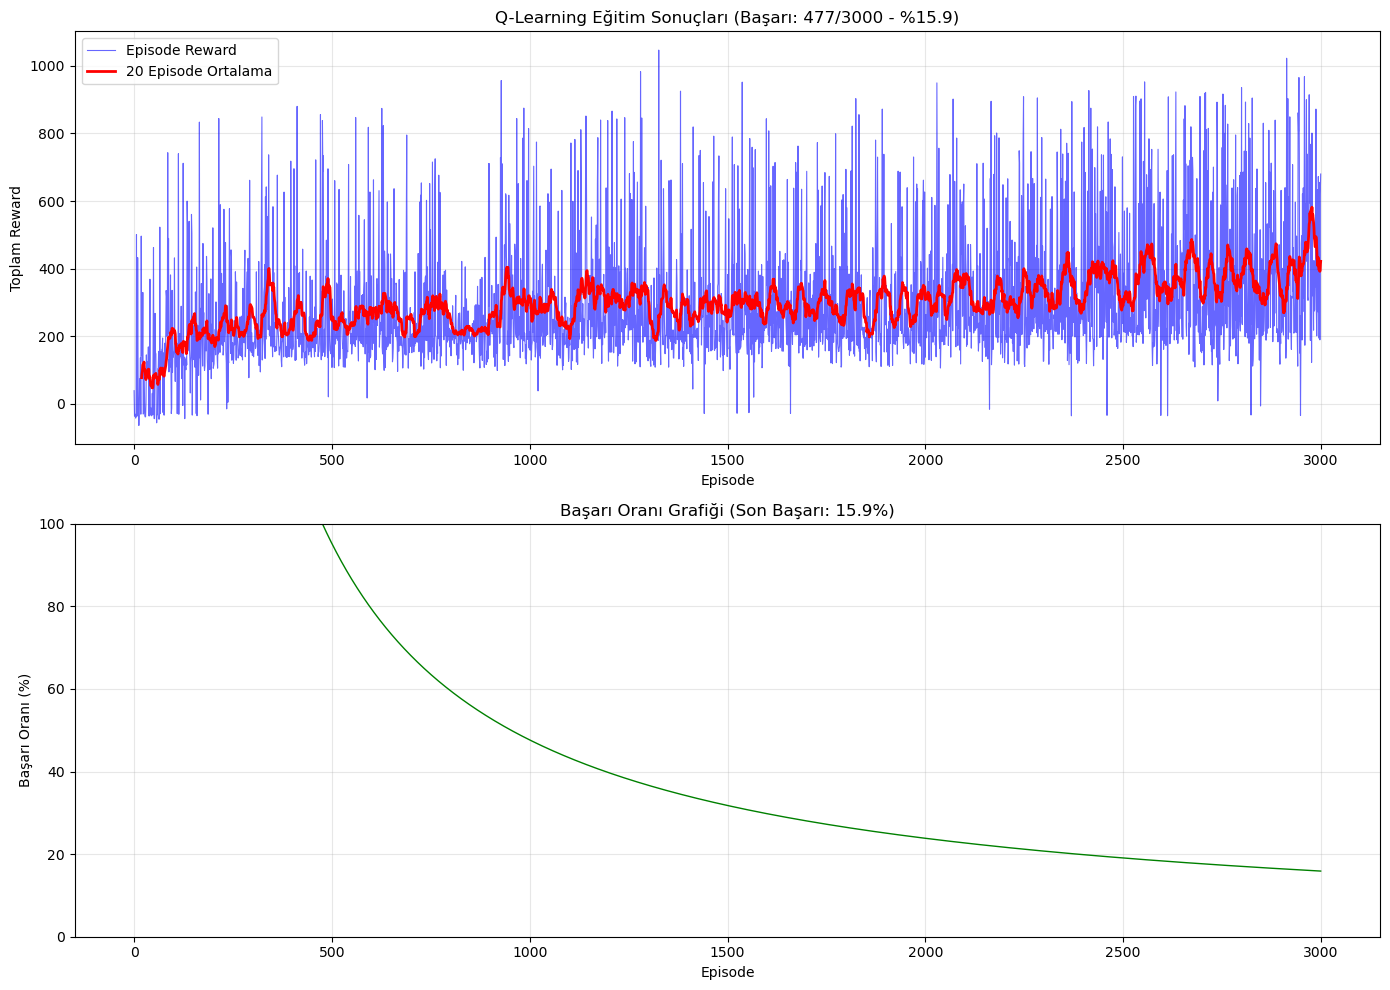


🎉 İşlem tamamlandı! Toplam Episode: 3000
📁 Son model kaydedildi: qlearning_final_model.pkl
📸 Görseller 'training_screenshots' klasörüne kaydedildi.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import math
import random
import time
import os
import pickle
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

print("=" * 80)
print(" TURTLEBOT3 Q-LEARNING EĞİTİMİ - İYİLEŞTİRİLMİŞ")
print("=" * 80)
print(" 7 LIDAR noktası → 4 seviyeye diskretize edildi")
print()

# Robot eğitim ortamı
class RobotEnv:
    #constructor methodu
    def __init__(self, render=False): # canlı similasyon kapatılmıştır.
        self.render_mode = render
        self.robot_radius = 0.25 # robotun gövde yarıçapı, çarpışma ve mesafe belirleme anında kullanılacaktır.
        self.goal_radius = 0.25 # hedef noktasının yarı çapıdır.
        self.lidar_range = 3.0 # lidar lazerlerinin maksimum mesafesidir.
        self.num_lidar = 7 # lidar 7 tane ışına sahiptir.
        self.lidar_angles = np.linspace(-np.pi/2, np.pi/2, self.num_lidar) # 7 tane lidar ışını -90 ile + 90 arasına yerleştirildi.
        
        #Ortamda bulunan duvarlar
        self.walls = [
            (-4, -4, 8, 0.4), (-4, 4, 8, 0.4),
            (-4, -4, 0.4, 8), (4, -4, 0.4, 8),
            (-2, -1, 1.2, 0.3), (1, 1, 1.2, 0.3),
            (0, -2, 0.3, 1.2), (-1, 2, 0.3, 1.0)
        ]
        
        # Klasör oluştur (eğitim görselleri için)
        self.screenshot_dir = "training_screenshots"
        if not os.path.exists(self.screenshot_dir):
            os.makedirs(self.screenshot_dir)
            
        # her eğitimden sonra ortam hazırlanır ve robot başlangıç konumuna alınır.
        self.reset()

    # lidar simüle fonksiyonu. robot bulunduğu noktadan 7 farklı ışın göndererek uzaklık almayı sağlar.
    def _get_lidar(self):
        readings = [] # mesafelerin tutulacağı liste
        for angle in self.lidar_angles: # -90 ile 90 derecesi arasındaki lidar derecelerini tek tek döndürür
            beam_angle = self.robot_theta + angle # robotun açısıyla ışının açısını toplarız
            hit_dist = self.lidar_range # mesafe 3 metreye eşitlenir

            # robotun konumu ile duvar konumlarına bakarak çarpışma var mı yok mu kontrol edilir.
            for wx, wy, ww, wh in self.walls: # duvar konunlları dönülür
                for t in np.linspace(0, self.lidar_range, 30): # 0 ile 3 metre arasını 30 parçaya böleriz. lazer ışını parça parça gönderilir.
                    # lazer koordinatları hesaplanır.
                    px = self.robot_x + t * np.cos(beam_angle) 
                    py = self.robot_y + t * np.sin(beam_angle)
                    # lazerin duvara çarpıp çarpmadığını anlarız
                    # en yakın olan duvar görürüz
                    if (wx - ww/2 <= px <= wx + ww/2) and (wy - wh/2 <= py <= wy + wh/2):
                        if t < hit_dist:
                            hit_dist = t
                        break
            # en yakın mesafe listelenir            
            readings.append(hit_dist)
        return np.array(readings)

        # sürekli veri kesikli hale getiriliyor böylece qlearning bu veriyi anlayabilecek
        # robot 4 durumu bilir (çok yakın, yakın, orta, uzak)
    def _discretize_lidar(self, lidar_meters):
        discretized = []
        for dist in lidar_meters: # 7 lazerin herbirinin ölçtüğü mesafeleri döner
            # dönülen mesafeler bir 4 sayıya yuvarlanır. Robot 0 gördüğünde çok yakon olduğunu anlar.
            if dist < 0.3:
                discretized.append(0) # çok yakın
            elif dist < 0.6:
                discretized.append(1) # yakın
            elif dist < 1.2:
                discretized.append(2) # orta
            else:
                discretized.append(3) # uzak (yol açık) 
        return tuple(discretized)

        # hedefe olan mesafe ve açıyı diskirize etmek için kullanılır
    def _discretize_goal(self, dist, angle):
        if dist < 0.4:
            dist_bucket = 0
        elif dist < 0.8:
            dist_bucket = 1
        elif dist < 1.5:
            dist_bucket = 2
        elif dist < 3.0:
            dist_bucket = 3
        else:
            dist_bucket = 4
        
        angle_normalized = angle / np.pi # robotun açısı -pi ile pi'den -1 ile 1 arasına diskrit ediyor
        angle_bucket = min(7, max(0, int((angle_normalized + 1) * 4)))
        # sonuç olarak robotun eterafının 8 parçaya böler.
        return dist_bucket, angle_bucket
    # her episode'de çağrılır. ama. her eğitimde her robotu başlangıç konumuna almak ve alanı temizlemek
    def reset(self):
        self.robot_x = -3.5
        self.robot_y = -3.5
        self.robot_theta = 0.0
        self.goal_x = np.random.uniform(-2.5, 2.5)
        self.goal_y = np.random.uniform(-2.5, 2.5)
        self.steps = 0
        self.max_steps = 600
        self.done = False
        self.trajectory_x = [self.robot_x]
        self.trajectory_y = [self.robot_y]
        return self._get_discretized_state()
    
    # sensör verilerini toplar ve basileştirir.
    # yapılan tüm diskrit işlemleri nihai sonuca getirir
    def _get_discretized_state(self):
        lidar_meters = self._get_lidar()
        lidar_state = self._discretize_lidar(lidar_meters)
        # Hedef ile aradaki mesafeyi (kuş bakışı) hesaplama
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        # hedeffe doğru dönmesi gereken açıyı hesaplama
        angle = math.atan2(dy, dx) - self.robot_theta
        angle = (angle + np.pi) % (2*np.pi) - np.pi
        
        dist_bucket, angle_bucket = self._discretize_goal(dist, angle)
        
        return lidar_state + (dist_bucket, angle_bucket)
    # robotu hareket ettiren  ve karar verdiren fonksiyondur
    def step(self, action):
        angular_vel = [-1.0, -0.5, 0, 0.5, 1.0][action] # gelen aksiyona gele döndürür
        linear_vel = 0.18 # ileri hız
        # robotun haritadaki yeni koordinatlarını hesaplar, "0.1" zaman adımını temsil eder.
        self.robot_theta += angular_vel * 0.1
        self.robot_x += linear_vel * np.cos(self.robot_theta) * 0.1
        self.robot_y += linear_vel * np.sin(self.robot_theta) * 0.1
        
        self.steps += 1 # robotun kaç adım attığını sayar.
        # robotun geçtiği yolları çizdirmek için kullanılır.
        self.trajectory_x.append(self.robot_x)
        self.trajectory_y.append(self.robot_y)
        
        # Çarpışma kontrolü
        # robotun yarı çapı eğer robot ile duvar arasındaki mesafeden uzunsa robot duvara çarptı demek.
        collision = False
        for wx, wy, ww, wh in self.walls:
            closest_x = max(wx - ww/2, min(self.robot_x, wx + ww/2))
            closest_y = max(wy - wh/2, min(self.robot_y, wy + wh/2))
            if np.sqrt((self.robot_x - closest_x)**2 + (self.robot_y - closest_y)**2) < self.robot_radius:
                collision = True
                break
        
        # ödüller burada belirlenmektedir.

        # hedefe olan mesafe
        dx = self.goal_x - self.robot_x
        dy = self.goal_y - self.robot_y
        dist = np.sqrt(dx*dx + dy*dy)
        
        if collision:
            reward = -30 # duvara çarparsa -30 puan
            self.done = True
        elif dist < self.goal_radius + self.robot_radius:
            reward = 100 # hedefi yakalarsa +100 puan
            self.done = True
        elif self.steps >= self.max_steps:
            reward = -20 # maksimum adım sayısını aşarsa - 20 puan ve episode biter
            self.done = True # episode bitti anlamına gelir
        else:
            angle_to_goal = math.atan2(dy, dx) - self.robot_theta
            angle_to_goal = (angle_to_goal + np.pi) % (2*np.pi) - np.pi
            angle_reward = max(-0.5, 1 - (abs(angle_to_goal) / (np.pi/2))) * 0.8 # robot açısı hedefe dönük olunca puan alır "0-1"
            dist_reward = 3.0 / (dist + 0.5) # robot hedefe yaklaştıkça puan alır "0.3" Hedef robotu mıknatıs gibi çeker.

            # robot duvara çok yaklaştığında ceza alır.
            lidar = self._get_lidar()
            min_dist = np.min(lidar)
            obstacle_penalty = 0
            if min_dist < 0.4:
                obstacle_penalty = -5 * (0.4 - min_dist) / 0.4 
            elif min_dist < 0.8:
                obstacle_penalty = -1 * (0.8 - min_dist) / 0.4
            
            survival_reward = 0.05 # robot hayatta kaldığı sürece aldığı ödül
            reward = angle_reward + dist_reward + obstacle_penalty + survival_reward
        
        return self._get_discretized_state(), reward, self.done, dist
    
    # traning esnasında her bölüm sonunda ortamın görüntüsü kayıt edilir.
    def save_screenshot(self, episode, total_reward, success_rate, action, distance):
        """Episode sonunda görsel kaydet"""
        try:
            fig, ax = plt.subplots(figsize=(14, 10))
            ax.set_xlim(-5, 5)
            ax.set_ylim(-5, 5)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.set_title(f'TurtleBot3 Q-Learning Eğitimi - Episode {episode}', fontsize=14, fontweight='bold')
            
            # Duvarlar
            for wx, wy, ww, wh in self.walls:
                rect = Rectangle((wx - ww/2, wy - wh/2), ww, wh, color='gray', alpha=0.6)
                ax.add_patch(rect)
            
            # Yol izi
            if len(self.trajectory_x) > 1:
                ax.plot(self.trajectory_x, self.trajectory_y, 'b--', linewidth=1, alpha=0.5, label='İz')
            
            # LIDAR
            lidar_meters = self._get_lidar()
            for i, angle in enumerate(self.lidar_angles):
                beam_angle = self.robot_theta + angle
                dist = lidar_meters[i]
                color = 'red' if dist < 0.4 else 'orange' if dist < 0.8 else 'green'
                ax.plot([self.robot_x, self.robot_x + dist*np.cos(beam_angle)],
                        [self.robot_y, self.robot_y + dist*np.sin(beam_angle)], 
                        color, linewidth=1.5, alpha=0.7)
            
            # Robot
            robot = Circle((self.robot_x, self.robot_y), self.robot_radius, color='blue', fill=False, linewidth=3)
            ax.add_patch(robot)
            ax.arrow(self.robot_x, self.robot_y, 0.5*np.cos(self.robot_theta), 
                     0.5*np.sin(self.robot_theta), head_width=0.2, head_length=0.2, 
                     fc='darkblue', ec='darkblue', linewidth=2)
            
            # Hedef
            goal = Circle((self.goal_x, self.goal_y), self.goal_radius, color='red', alpha=0.8, facecolor='red')
            ax.add_patch(goal)
            ax.text(self.goal_x, self.goal_y, '🎯', fontsize=16, ha='center', va='center')
            
            # Bilgi metni
            action_names = ['Sert Sol (-1.0)', 'Hafif Sol (-0.5)', 'Düz (0)', 'Hafif Sağ (+0.5)', 'Sert Sağ (+1.0)']
            
            info_text = f"""
╔════════════════════════════════════════════════════════╗
║                  EĞİTİM DURUM RAPORU                 ║
╠════════════════════════════════════════════════════════╣
║   Episode: {episode}                                          ║
║   Robot: ({self.robot_x:6.2f}, {self.robot_y:6.2f})                 ║
║   Hedef: ({self.goal_x:6.2f}, {self.goal_y:6.2f})                 ║
║   Hedefe Uzaklık: {distance:6.2f} m                          ║
║   Robot Açısı: {math.degrees(self.robot_theta):6.1f}°                          ║
║   Seçilen Aksiyon: {action_names[action]}          ║
║   Toplam Reward: {total_reward:8.2f}                              ║
║   Başarı Oranı: {success_rate:5.1f}%                                   ║
║   Adım: {self.steps:3d} / {self.max_steps}                                ║
╚════════════════════════════════════════════════════════╝
"""
            ax.text(-4.8, 4.2, info_text, fontsize=10, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='#E8F4FD', edgecolor='blue', linewidth=2))
            
            ax.legend(loc='lower right')
            plt.tight_layout()
            
            # Kaydet
            filename = f"{self.screenshot_dir}/episode_{episode:04d}.png"
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            print(f"📸 Görsel kaydedildi: {filename}")
            
            plt.close(fig)
            
        except Exception as e:
            print(f" Görsel kaydetme hatası: {e}")

# pekiştirmeli öğrenme sınıfı. eğtim için gerekli olan algoritma, parametre ve fonksiyonlar bu sınıfda yer almaktadır.
class QLearningAgent:
    def __init__(self, alpha=0.15, gamma=0.98, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.998):
        self.Q = {} # Q-Table
        # parametreler
        self.alpha = alpha # öğrenme hızı
        self.gamma = gamma # indirgeme faktörü
        self.epsilon = epsilon # keşif oranı, başta 1 dir zamanla 0'a yaklaşacaktır. sömürü başlayacaktır.
        self.epsilon_min = epsilon_min # azda olsa her zaman bir keşif olması için kullanıldı.
        self.epsilon_decay = epsilon_decay # keşiften sömürüye geçme hızı
        self.action_size = 5
    
    def _get_state_key(self, state): # sensör verilerini tuple bir metne çevirir
        return str(state)

        # belirli bir durumda yapılan hareketin puanı q-table'dan çekilir.
    def get_q(self, state, action):
        key = self._get_state_key(state)
        if key not in self.Q:
            self.Q[key] = [0.0] * self.action_size
        return self.Q[key][action]
    # alınan yeni puanı tabloya kayıt eder.
    def set_q(self, state, action, value):
        key = self._get_state_key(state)
        if key not in self.Q:
            self.Q[key] = [0.0] * self.action_size
        self.Q[key][action] = value
    
    # karar verme mekanizması, epsilon-decay hareket gerçekleşir
    def act(self, state):
        # keşif
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        
        key = self._get_state_key(state)
        
        if key not in self.Q:
            return random.randrange(self.action_size)
        
        return np.argmax(self.Q[key])
    # q-learning algoritmasının öğrenme merkezidir.
    # q tablosu güncellenir. belman deklemi içeren q learning algoritması burda yer alır.
    def update(self, state, action, reward, next_state, done):
        current_q = self.get_q(state, action) # q tablosundan bulunduğu state için yaptığı aksiyon puanını çeker. eski bilgi
        # episdoe bittiyse
        if done:
            target = reward
        # episode bitmediyse    
        else:
            # bulunduğu state en yüksek puanı getiren aksiyonun puanını alır.
            next_max_q = max(self.get_q(next_state, a) for a in range(self.action_size)) 
            target = reward + self.gamma * next_max_q # gelecekteki ödül hesaplanır
        
        new_q = current_q + self.alpha * (target - current_q) # en yüksek puanı alır
        self.set_q(state, action, new_q) # puan q tablosuna yazılır.
    
    # epsilonu azaltan fonksiyon 
    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
    
    def get_table_size(self):
        return len(self.Q)
    
    # model kayıt edilir.
    def save_model(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.Q, f)
        print(f" Q-tablosu kaydedildi: {filename}")


# ==================== EĞİTİM ====================
print("🚀 Q-Learning Eğitimi başlıyor...")
print(f" Max Steps: 600")
print(f" Her 50 episodeda bir görsel kaydedilecek")
print()

env = RobotEnv(render=False)
agent = QLearningAgent(alpha=0.15, gamma=0.98, epsilon=1.0, epsilon_decay=0.998)

EPISODES = 3000 # Bölüm sayısı
rewards_history = []
success_count = 0 # robotun hedefe ulaşma sayısı
start_time = time.time()

for episode in range(EPISODES):
    state = env.reset() # ortam resetleniyor
    total_reward = # her episode'da ödül 0'dan başlar
    done = False # true olursa episode biter
    step = 0 # episode sırasında toplam adım sayısı
    last_action = 2  # Varsayılan aksiyon

    # robotu bir sonuca ulanaşa kadar çalıştırır
    while not done:
        action = agent.act(state)
        next_state, reward, done, distance = env.step(action)
        
        agent.update(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        step += 1
        last_action = action
        
        if done:
            if reward >= 90:
                success_count += 1
            
            rewards_history.append(total_reward)
            success_rate = (success_count / (episode+1)) * 100
            
            # HER 50 EPISODEDE BİR GÖRSEL KAYDET
            if (episode + 1) == 1 or (episode + 1) % 50 == 0:
                env.save_screenshot(episode + 1, total_reward, success_rate, last_action, distance)
                
                elapsed = time.time() - start_time
                print(f" Episode {episode+1:4d}/{EPISODES} | "
                      f"Reward: {total_reward:8.2f} | "
                      f"Epsilon: {agent.epsilon:.3f} | "
                      f"Başarı: {success_count:4d}/{episode+1} (%{success_rate:5.1f}) | "
                      f"Q-Tablo: {agent.get_table_size():5d} | "
                      f"⏱️: {int(elapsed//60)}:{int(elapsed%60):02d}")
            else:
                # Sadece terminal çıktısı (görsel yok)
                if (episode + 1) % 50 == 0:
                    pass
                elif (episode + 1) % 10 == 0:  # Her 10 episodeda kısa çıktı
                    print(f"Episode {episode+1:4d}/{EPISODES} | Reward: {total_reward:7.2f} | Başarı: {success_count:4d} (%{success_rate:5.1f})")
            
            break
    
    agent.decay_epsilon()
    
    # HER 500 EPISODEDE BİR MODEL KAYDET
    if (episode + 1) % 500 == 0:
        agent.save_model(f"qlearning_model_ep{episode+1}.pkl")

# SON MODELİ KAYDET
agent.save_model("qlearning_final_model.pkl")

# EĞİTİM SONUÇLARI
print()
print("=" * 80)
print(" Q-LEARNING EĞİTİMİ TAMAMLANDI!")
print(f" Toplam Başarı: {success_count}/{EPISODES} (%{(success_count/EPISODES)*100:.1f})")
print(f" Ortalama Reward (son 50): {np.mean(rewards_history[-50:]):.2f}")
print(f" En İyi Reward: {max(rewards_history):.2f}")
print(f" En Kötü Reward: {min(rewards_history):.2f}")
print(f" Q-Tablosu boyutu: {agent.get_table_size()}")
print("=" * 80)

# TEST
print()
print(" TEST - Eğitilmiş Q-Learning modeli ile...")
agent.epsilon = 0
state = env.reset()
done = False
total_reward = 0
step = 0

while not done:
    action = agent.act(state)
    state, reward, done, _ = env.step(action)
    total_reward += reward
    step += 1

print(f" TEST SONUCU: Reward={total_reward:.2f}, Steps={step}")
if total_reward > 50:
    print(" Robot hedefe başarıyla ulaştı!")
elif total_reward > 20:
    print(" Kısmi başarı, daha fazla eğitim gerekli")
else:
    print(" Başarısız, eğitim parametreleri ayarlanmalı")

# ==================== FİNAL GRAFİK (EPİSODE-REWARD) ====================
print()
print(" Eğitim grafikleri hazırlanıyor...")

plt.figure(figsize=(14, 10))

# Grafik 1: Tüm Eğitim Reward'ları
plt.subplot(2, 1, 1)
plt.plot(rewards_history, 'b-', linewidth=0.8, alpha=0.6, label='Episode Reward')
if len(rewards_history) > 20:
    avg = np.convolve(rewards_history, np.ones(20)/20, mode='valid')
    plt.plot(range(19, len(rewards_history)), avg, 'r-', linewidth=2, label='20 Episode Ortalama')
plt.xlabel('Episode')
plt.ylabel('Toplam Reward')
plt.title(f'Q-Learning Eğitim Sonuçları (Başarı: {success_count}/{EPISODES} - %{(success_count/EPISODES)*100:.1f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafik 2: Başarı Oranı
plt.subplot(2, 1, 2)
success_rates = [success_count / max(1, i+1) * 100 for i in range(EPISODES)]
plt.plot(success_rates, 'g-', linewidth=1)
plt.xlabel('Episode')
plt.ylabel('Başarı Oranı (%)')
plt.title(f'Başarı Oranı Grafiği (Son Başarı: {(success_count/EPISODES)*100:.1f}%)')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print(f" İşlem tamamlandı! Toplam Episode: {EPISODES}")
print(f" Son model kaydedildi: qlearning_final_model.pkl")
print(f" Görseller '{env.screenshot_dir}' klasörüne kaydedildi.")